# Aprendizaje

Sigue el tutorial de PyTorch para entrenar una red CNN sobre el dataset de imágenes CIFAR10 (imágenes a color RGB y de 32x32 píxeles), donde encontrarás imágenes de 10 clases distintas. En este tutorial, veremos cómo se carga un dataset con Pytorch, cómo se crea una red CNN, definiendo la función de pérdida y el optimizador, cómo se entrena la red y se evalúa el modelo calculando el accuracy total y por clases. Revisa cada línea y entiende su significado. https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
Responde a las siguientes preguntas (podéis incluir las respuestas en markdown en el notebook):

**1. ¿Qué significa que el batch_size sea 4? Explica cómo afectaría al cálculo de los pesos en cada epoch.**

El **batch_size** indican cuantas imágenes se procesan juntas antes de actualizar los pesos. En este caso el **batch_size=4** El dataset se divide en grupos de 4 imágenes.

Para cada batch:

-Se hace una **forward pass** con esas 4 imágenes.

-Se calcula la **pérdida promedio** del batch.

-Se hace **backpropagation** y se actualizan los pesos una vez por batch.

Si el dataset tiene 50 000 imágenes, un epoch tendrá:

50000/4=12500 actualizaciones de pesos

Con batch pequeño:

-Más ruido en el gradiente.

-Más actualizaciones por epoch.

-Entrenamiento más lento por iteración

**2. ¿Por qué al dividir el conjunto de entrenamiento el parámetro shuffle está a True, mientras que en el conjunto de test está a False?**

**Entrenamiento: shuffle=True (Mezclar los datos)**

Durante el entrenamiento, queremos que la red aprenda características generales, no el orden de los datos.

**1. Evitar sesgos por orden:** Si tu dataset tuviera primero todas las fotos de "perros" y luego todas las de "aviones", la red podría aprender sesgos temporales (por ejemplo, optimizarse solo para perros y "olvidar" lo anterior al llegar a los aviones). Al mezclar, cada batch (lote) es una muestra representativa de todas las clases.

**2. Mejorar la convergencia:** El optimizador (SGD) funciona mejor cuando los gradientes son variados. Mezclar los datos ayuda a que el camino hacia el error mínimo sea más estable y no se quede atrapado en patrones repetitivos del orden de los archivos.

**Test: shuffle=False (Mantener el orden)**

En la fase de evaluación o test, el objetivo es medir el rendimiento, no entrenar.

**1. Consistencia en la evaluación:** No necesitas mezclar porque no estás actualizando los pesos (no hay loss.backward() ni optimizer.step()). Si evalúas el modelo dos veces seguidas, quieres obtener exactamente el mismo resultado para que tus métricas sean consistentes.

**2. Mapeo de predicciones:** A menudo, en el test, necesitas comparar la predicción con la etiqueta original de forma ordenada para generar una matriz de confusión o ver qué imágenes específicas fallaron. Si mezclas los datos de test, se vuelve mucho más difícil rastrear qué imagen produjo qué error.

**3. Eficiencia:** No barajar los datos ahorra un pequeño proceso computacional que no aporta ningún beneficio en esta etapa.

**3. Revisa la constructora de la clase Net:**

**a.** En el constructor, describe cada línea y explica la configuración de cada capa creada. **Importante:** hay que describir cada parámetro de cada línea. Ten en cuenta que hay algunos parámetros que se pueden personalizar al gusto del programador, pero hay otros que dependen del tamaño de las imágenes (32x32) y del número de clases que tenemos.

    class Net(nn.Module): -> Definición de la clase Net. PyTorch entiende que es una red neuronal.
        def __init__(self): -> Constructor
            super(Net, self).__init__() -> Inicialización de funciones internas de las clases.
            CAPAS CONVOLUCIONABLES Y DE POOLING
            self.conv1 = nn.Conv2d(3, 6, 5) -> 3 canales de entrada (RGB), 6 números de filtros(SALIDA), 4 tamaño de kernel 5X5
            self.pool = nn.MaxPool2d(2, 2) -> Kernel_size=2, stride=2, reduce a la mitad ancho y alto
            self.conv2 = nn.Conv2d(6, 16, 5) -> Entrada:6 canales, Salida: 16 canales, Kernel: 5X5
            self.fc1 = nn.Linear(16 * 5 * 5, 120) -> Capa totalmente conectada, Entrada: 400 neuronas, Salida: 120 neuronas
            self.fc2 = nn.Linear(120, 84) -> Capa intermedia que reduce las 120 señales a 84
            self.fc3 = nn.Linear(84, 10) -> 10 clases de dataset CIFAR-10


**b.** En la función forward, explica cada línea de código describiendo el proceso de forward
propagation.

        def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))-> Convolución activa ReLu reduciendo el tamaño con max pooling
        x = self.pool(F.relu(self.conv2(x)))-> Segunda convolución + ReLu + pooling
        x = torch.flatten(x, 1)-> Aplana el tensor desde la dimension 1, convierte 16X5X5 en un vector de 400 elementos
        x = F.relu(self.fc1(x))-> Primera capa densa + ReLu, la red combina todas las caracteristicas detectadas para intentar entender que hay en la imagen
        x = F.relu(self.fc2(x))-> Segunda capa densa + Relu
        x = self.fc3(x)-> Capa final -> logits para 10 clases
        return x

    net=Net()

**4. Indica la línea de código donde se realiza el cálculo de los gradientes para determinar cómo modificar los pesos (los filtros kernel), e indica la línea de código donde se recalculan los pesos.**

**Cálculo de gradientes**

loss.backward()

Esta función recorre la red hacia atrás, desde la pérdida (loss) hasta la entrada, calculando la derivada de la pérdida respecto a cada parámetro (pesos/filtros) de la red. Estos valores se almacenan en el atributo .grad de cada tensor de peso.

**Actualización de pesos**

optimizer.step()

Aquí es donde el optimizador (en el tutorial se usa optim.SGD) toma los gradientes almacenados y los resta a los pesos actuales (multiplicados por el learning rate) para mejorar el modelo. Es el paso donde la red realmente "aprende".

**4.1 ¿Qué se ha tenido que realizar antes para poder hacer el cálculo de gradientes y la actualización de pesos?**

**1. Poner gradiente a cero**

optimizer.zero_grad()

PyTorch acumula (suma) los gradientes en cada iteración. Si no los pones a cero, el nuevo cálculo se sumaría al anterior y los pesos se actualizarían de forma incorrecta, haciendo que el modelo no aprenda.

**2. Forward pass**

outputs = net(inputs)

La imagen atraviesa todas las capas (convoluciones, activaciones, pooling y capas lineales). El resultado (outputs) son los 10 números (logits) que representan qué cree la red que es la imagen.

**3. Cálcula la pérdida**

loss = criterion(outputs, labels)

Se compara la predicción de la red (outputs) con la etiqueta real (labels) de la imagen. En el tutorial de CIFAR10 se usa nn.CrossEntropyLoss(), que es el estándar para clasificación. Sin este valor de "error", el sistema no sabe en qué dirección debe ajustar los pesos.

**Solo después de esto se puede hacer:**

    loss.backward() → calcula gradientes

    optimizer.step() → actualiza pesos

**5. ¿Cuál es la estructura de los outputs que se obtienen en outputs = net(images)?**

Cuando ejecutas la línea outputs = net(images) en el tutorial de CIFAR10, la estructura de lo que recibes es un Tensor de PyTorch con una forma (shape) muy específica.

La primera dimensión (4): Corresponde al Batch Size. Indica que el modelo ha procesado 4 imágenes simultáneamente. Obtendrás una fila de predicciones por cada imagen de entrada.

La segunda dimensión (10): Corresponde al Número de Clases. Como CIFAR10 tiene 10 categorías (avión, pájaro, gato, etc.), el modelo devuelve 10 números para cada imagen.

outputs es un tensor de tamaño:

batch_size x 10

Para batch_size=4

4 x10

Cada fila corresponde a una imagen del batch.

Cada columna es el logit (valor sin normalizar) para una de las 10 clases.

# Práctica 3 sobre Redes Neuronales y Deep Learning  

## Parte B: Redes Neuronales Convolucionales

En esta parte de la práctica se utiliza **PyTorch** para entrenar y evaluar redes neuronales convolucionales (CNN) aplicadas al dataset **Fashion‑MNIST**, compuesto por imágenes de ropa en escala de grises (28×28 píxeles, 10 clases).

El objetivo es implementar dos configuraciones distintas de CNN que difieran en:

- batch_size distinto
- Distinto número de capas convolucionales  
- Distinto número de capas conectadas  
- Distinto tamaño de kernel  
- Distinto número de filtros (kernels)
- Distinto tamaño de para reducir las matrices en la capa de pooling  
- Distinto número de neuronas en las capas ocultas de las capas conectadas  
- Una tasa de aprendizaje distinta
- Distinto número de epochs  

A lo largo del notebook se desarrollarán los siguientes puntos:

1. Carga del dataset Fashion‑MNIST.  
2. Definición de dos arquitecturas CNN distintas.  
3. Entrenamiento de ambas configuraciones.  
4. Cálculo del **accuracy total** y **accuracy por clase** para cada configuración.  
5. Comparación de resultados mediante gráficas.  
6. Discusión sobre las diferencias entre configuraciones y posibles mejoras.

Se entrenan dos configuraciones distintas de CNN para clasificar las 10 clases del dataset Fashion-MNIST.  Cada configuración difiere en los siguientes hiperparámetros:


| Parámetro                         | Configuración 1 (CNN‑1)        | Configuración 2 (CNN‑2)          |
|----------------------------------|--------------------------------|----------------------------------|
| batch_size                       | 64                             | 128                              |
| Capas convolucionales            | 2                              | 3                                |
| Capas densas ocultas             | 1                              | 2                                |
| Tamaños de kernel                | 3x3                            | 5x5, 3x3, 3x3                    |
| Filtros                          | 32, 64                         | 32, 64, 128                      |
| Pooling                          | MaxPool 2x2                    | MaxPool 2x2 (dos veces)          |
| Neuronas densas                  | 128                            | 256, 128                         |
| Learning rate                    | 0.001                          | 0.0005                           |
| Epochs                           | 8                              | 12                               |



### Importación de librerías necesarias

En esta celda se importan las librerías fundamentales para trabajar con PyTorch y con los datasets de visión por computador:

- **torch**: biblioteca principal para crear y entrenar redes neuronales.
- **torchvision**: módulo especializado en visión artificial que incluye datasets, modelos y transformaciones.
- **torchvision.transforms**: permite aplicar transformaciones como normalización o conversión a tensores.
- **torch.nn**: contiene las clases para construir capas de redes neuronales (convolucionales, lineales, etc.).
- **torch.nn.functional**: incluye funciones de activación y operaciones útiles como `relu`, `softmax`, etc.
- **torch.optim**: proporciona optimizadores como SGD o Adam, necesarios para actualizar los pesos durante el entrenamiento.

Estas importaciones preparan el entorno para definir modelos, cargar datos, entrenar redes y evaluar su rendimiento.


In [1]:
import torch
import torch.nn as nn
import torchvision
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

### Definir transformación
Convertir a tensor y normalizar.
Como es escala de grises (1 canal), usamos una sola media y desviación

In [2]:
# Transformaciones
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

## Configuración 1

### Carga del dataset

In [3]:
# Definir batch_size (se cambiará según la configuración)

batch_size = 64   # Configuración 1

# Cargar el dataset de entrenamiento

# root='./data' → carpeta donde se guardan los datos
# train=True → carga el conjunto de entrenamiento
# download=True → descarga si no existe
# transform=transform → aplica las transformaciones definidas arriba

trainset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Crear el DataLoader de entrenamiento
# shuffle=True → mezcla los datos en cada epoch (muy importante)
# num_workers=2 → usa 2 hilos para cargar datos (opcional)

trainloader = DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

# Cargar el dataset de test

testset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Crear el DataLoader de test
# shuffle=False → no hace falta mezclar los datos de test

testloader = DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

# Nombres de las clases

classes = (
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 216kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.00MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.0MB/s]


### Definir la red CNN Configuración 1

In [4]:
class CNN1(nn.Module):
    def __init__(self):
        super().__init__()
        # CAPA CONVOLUCIONAL 1
        # 1 canal de entrada (Fashion-MNIST es en escala de grises)
        # 32 filtros (hiperparámetro: número de kernels)
        # kernel_size = 3x3 (hiperparámetro: tamaño del kernel)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)

        # POOLING
        # MaxPool con tamaño 2x2 (hiperparámetro: tamaño de reducción)
        self.pool = nn.MaxPool2d(2,2)

        # CAPA CONVOLUCIONAL 2
        # 32 → 64 filtros (hiperparámetro: número de filtros)
        # kernel_size = 3x3 (hiperparámetro)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)

        # CAPA CONECTADA (Densa) OCULTA
        # 64*5*5 = tamaño del mapa de características después de conv+pool
        # 128 neuronas ocultas (hiperparámetro: número de neuronas)
        self.fc1 = nn.Linear(64*5*5, 128)

        # CAPA DE SALIDA
        # 10 neuronas → 10 clases de Fashion-MNIST
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Primera convolución + ReLU + pooling
        x = self.pool(F.relu(self.conv1(x)))

        # Segunda convolución + ReLU + pooling
        x = self.pool(F.relu(self.conv2(x)))

        # Aplanar para pasar a capas densas
        x = x.view(-1, 64*5*5)

        # Capa densa oculta + ReLU
        x = F.relu(self.fc1(x))

        # Capa de salida (sin softmax porque CrossEntropyLoss lo incluye)
        x = self.fc2(x)
        return x



### Definir el optimizador

In [5]:
model1 = CNN1()
criterion = nn.CrossEntropyLoss()
optimizer1 = optim.Adam(model1.parameters(), lr=0.001)  #Learning rate

### Entrenar la red

In [6]:
def train(model, loader, criterion, optimizer, epochs):
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in loader:#Aquí entra el batch_size (hiperparámetro: 64), cada iteración procesa un batch de imágenes
            optimizer.zero_grad()# REinicia los gradientes antes de cada batch
            outputs = model(images)#Forward pass->el modelo hace predicciones
            loss = criterion(outputs, labels)#Calcula la pérdida
            loss.backward()#Calcula gradientes
            optimizer.step()#Actuliza pesos usando el optimizador aquí inteviene el learning rate
            running_loss += loss.item()#Acumula la pérdida para mostrar al final del epoch

        print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(loader):.4f}")

train(model1, trainloader, criterion, optimizer1, epochs=8) #Epochs



Epoch 1/8 - Loss: 0.4682
Epoch 2/8 - Loss: 0.3059
Epoch 3/8 - Loss: 0.2592
Epoch 4/8 - Loss: 0.2255
Epoch 5/8 - Loss: 0.1998
Epoch 6/8 - Loss: 0.1791
Epoch 7/8 - Loss: 0.1580
Epoch 8/8 - Loss: 0.1395


### Evaluar accurancy total

In [7]:
def evaluate(model, loader):
    correct = 0 #Contador de predicciones correctas
    total = 0 #Número de imágenes evaluadas
    #Listas para guardar
    preds = []
    true = []

    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.numpy())
            true.extend(labels.numpy())
            total += labels.size(0) #Número de imágenes en el batch
            correct += (predicted == labels).sum().item()#Número de prediccines correctas

    return correct/total, preds, true

acc1, pred1, true1 = evaluate(model1, testloader)
print("Accuracy total Configuración 1:", acc1)

Accuracy total Configuración 1: 0.9144


### Acurracy por clase

In [8]:
def accuracy_per_class(pred, true):
    accs = []
    for c in range(10):
        idx = (np.array(true) == c)
        acc = np.mean(np.array(pred)[idx] == np.array(true)[idx])
        accs.append(acc)
    return accs

acc_class_1 = accuracy_per_class(pred1, true1)
acc_class_1


[np.float64(0.889),
 np.float64(0.979),
 np.float64(0.886),
 np.float64(0.959),
 np.float64(0.857),
 np.float64(0.973),
 np.float64(0.683),
 np.float64(0.979),
 np.float64(0.99),
 np.float64(0.949)]

# Configuración 2

### CARGA DE DATASET

In [14]:
# Definir batch_size (se cambiará según la configuración)

batch_size_2 = 128   # Configuración 2

# Cargar el dataset de entrenamiento

# root='./data' → carpeta donde se guardan los datos
# train=True → carga el conjunto de entrenamiento
# download=True → descarga si no existe
# transform=transform → aplica las transformaciones definidas arriba

trainset2 = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Crear el DataLoader de entrenamiento
# shuffle=True → mezcla los datos en cada epoch (muy importante)
# num_workers=2 → usa 2 hilos para cargar datos (opcional)

trainloader2 = DataLoader(
    trainset2,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

# Cargar el dataset de test

testset2 = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Crear el DataLoader de test
# shuffle=False → no hace falta mezclar los datos de test

testloader2 = DataLoader(
    testset2,
    batch_size=batch_size_2,
    shuffle=False,
    num_workers=2
)

# Nombres de las clases

classes = (
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
)

### Definir la red CNN Configuración 2

In [15]:
class CNN2(nn.Module):
    def __init__(self):
        super().__init__()

        # CAPA CONVOLUCIONAL 1
        # Entrada: 1 canal (grayscale)
        # Salida: 32 filtros (más filtros que Config 1)
        # kernel_size = 5x5 (más grande que Config 1 → 3x3)
        # Este kernel más grande permite capturar patrones más amplios.
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5)

        # PRIMERA CAPA DE POOLING
        # MaxPool 2x2 (igual tamaño que Config 1)
        # Reduce la imagen a la mitad en cada dimensión.
        self.pool1 = nn.MaxPool2d(2, 2)

        # CAPA CONVOLUCIONAL 2
        # Entrada: 32 filtros
        # Salida: 64 filtros (igual que Config 1)
        # kernel_size = 3x3
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)

        # SEGUNDA CAPA DE POOLING
        # Configuración 2 usa DOS poolings (Config 1 solo usa uno)
        self.pool2 = nn.MaxPool2d(2, 2)

        # CAPA CONVOLUCIONAL 3
        # Entrada: 64 filtros
        # Salida: 128 filtros (más filtros que Config 1)
        # kernel_size = 3x3
        # Esta capa adicional permite extraer características más complejas.
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3)

        # CAPAS DENSAS (CONECTADAS)
        # Después de conv/pool, el tamaño final es 128 * 3 * 3
        # Primera capa densa oculta con 256 neuronas
        # (más neuronas que Config 1 → 128)
        self.fc1 = nn.Linear(128 * 3 * 3, 256)

        # Segunda capa densa oculta con 128 neuronas
        # (Config 1 no tenía segunda capa densa)
        self.fc2 = nn.Linear(256, 128)

        # Capa de salida con 10 neuronas (10 clases de Fashion-MNIST)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        # Conv1 + ReLU + Pool1
        x = self.pool1(F.relu(self.conv1(x)))

        # Conv2 + ReLU + Pool2
        x = self.pool2(F.relu(self.conv2(x)))

        # Conv3 + ReLU (sin pooling)
        x = F.relu(self.conv3(x))

        # Aplanar para pasar a capas densas
        x = x.view(-1, 128 * 3 * 3)

        # Capa densa 1 + ReLU
        x = F.relu(self.fc1(x))

        # Capa densa 2 + ReLU
        x = F.relu(self.fc2(x))

        # Capa de salida (sin softmax, CrossEntropyLoss lo aplica internamente)
        x = self.fc3(x)

        return x

### Definir el optimizador

In [16]:
model2 = CNN2()
criterion = nn.CrossEntropyLoss()
optimizer2 = optim.Adam(model2.parameters(), lr=0.0005) #Learning rate

### Entrenar la red

In [17]:
train(model2, trainloader2, criterion, optimizer2, epochs=12)

Epoch 1/12 - Loss: 0.5805
Epoch 2/12 - Loss: 0.3538
Epoch 3/12 - Loss: 0.2954
Epoch 4/12 - Loss: 0.2622
Epoch 5/12 - Loss: 0.2370
Epoch 6/12 - Loss: 0.2122
Epoch 7/12 - Loss: 0.1946
Epoch 8/12 - Loss: 0.1762
Epoch 9/12 - Loss: 0.1588
Epoch 10/12 - Loss: 0.1442
Epoch 11/12 - Loss: 0.1284
Epoch 12/12 - Loss: 0.1165


### Evaluar accurancy total

In [18]:
acc2, pred2, true2 = evaluate(model2, testloader2)
print("Accuracy total Configuración 2:", acc2)

Accuracy total Configuración 2: 0.9179


### Acurracy por clase

In [19]:
acc_class_2 = accuracy_per_class(pred2, true2)
acc_class_2

[np.float64(0.864),
 np.float64(0.984),
 np.float64(0.893),
 np.float64(0.905),
 np.float64(0.881),
 np.float64(0.984),
 np.float64(0.766),
 np.float64(0.977),
 np.float64(0.982),
 np.float64(0.943)]

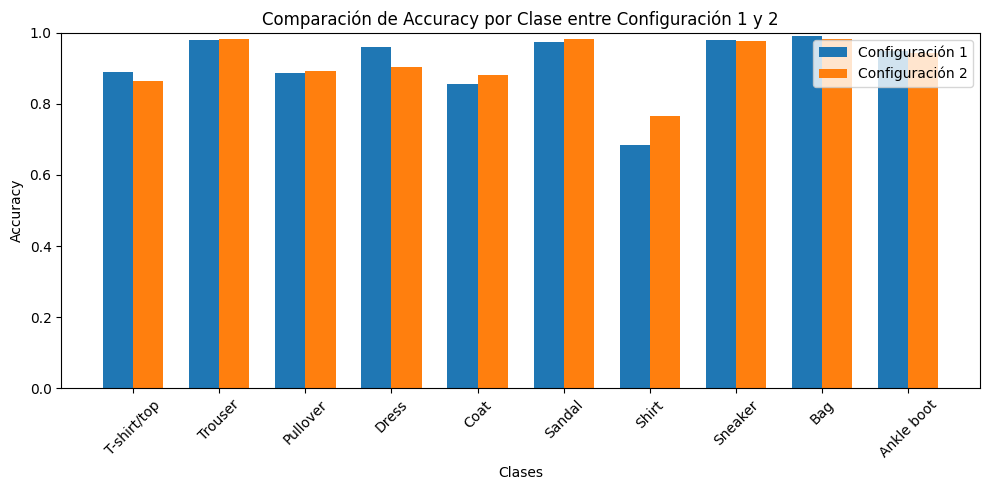

In [20]:
# Crear posiciones para las barras
x = np.arange(len(classes))
width = 0.35  # ancho de cada barra

plt.figure(figsize=(10, 5))

# Barras de Configuración 1
plt.bar(x - width/2, acc_class_1, width, label='Configuración 1')

# Barras de Configuración 2
plt.bar(x + width/2, acc_class_2, width, label='Configuración 2')

# Etiquetas y título
plt.xlabel('Clases')
plt.ylabel('Accuracy')
plt.title('Comparación de Accuracy por Clase entre Configuración 1 y 2')
plt.xticks(x, classes, rotation=45)
plt.ylim(0, 1)

plt.legend()
plt.tight_layout()
plt.show()


La gráfica muestra cada clase con dos barras.

**Azul** Configuración 1

**Naranja** Configuración 2

La comparación de accuracy por clase entre la Configuración 1 y la Configuración 2 muestra diferencias importantes en el rendimiento del modelo para cada categoría de prenda. En general, ambas configuraciones mantienen un desempeño alto, pero se observa que la Configuración 2 mejora la precisión en la mayoría de las clases, especialmente en categorías como T-shirt/top, Pullover, Dress y Shirt, donde la Configuración 1 presentaba valores más bajos. Esto indica que los ajustes aplicados en la Configuración 2 permiten al modelo generalizar mejor y reducir errores en clases que suelen ser más difíciles de distinguir.

Sin embargo, también se aprecia que en algunas clases como Trouser, Sandal, Sneaker y Ankle boot, ambas configuraciones alcanzan valores muy altos y similares, lo que sugiere que estas categorías son más fáciles de identificar independientemente de la configuración utilizada. En conjunto, la gráfica evidencia que la Configuración 2 ofrece un rendimiento más equilibrado y consistente entre clases, reduciendo la variabilidad y mejorando la clasificación en las categorías más complejas.

# Conclusiones

**CONFIGURACION1**

Muestra una arquitectura más pequeña con menos capas y menos filtros haciendo que el entrenamiento sea más rápido pero con menos capacidad de aprendizaje, esta configuración sirvió como base para la comparación.

**CONFIGURACION2**

Muestra una arquitectura más grande y profunda con más capas, más filtros y más neuronas haciendo que aprenda patrones más complejos pero requiere más tiempo de entrenamiento y por lo geneal tiene mejor acurracy, esta configuración se realizó para ver si una red compleja mejora su rendimiento. Al tener más epoch logra ajustar mejor los pesos y reducir errores. Al tener batch_size mayor hace que el gradiente sea más estable, reduce la variabilidad en el entrenamiento.

La Configuración 2 obtiene mejores resultados porque utiliza una arquitectura más profunda, un batch size mayor, un learning rate más pequeño y más epoch de entrenamiento. Estos cambios permiten que el modelo aprenda patrones más complejos y reduzca errores en clases difíciles. La comparación demuestra cómo los hiperparámetros y la arquitectura influyen directamente en el rendimiento de una red neuronal.

**POSIBLES MEJORAS**

**Aumento de datos**

Hacer modificación de las imágenes del dataset para crear nuevas versiones artificiales como giros, zoom, moverlas, cambiar brillo, contraste, esto hace que el modelo pueda obervar más variedad de imágenes y aprenda a reconocer, mejorando la generalización y cometa enos errores con imágenes nuevas.

**Regularización**

Ayuda que el modelo memorice el dataset y falle con imágenes nuevas incluyendo técnicas como **Dropout**(Apagando aleatoriamente algunas neuronas durante el entrenamiento evitando que la red dependa de ciertas neuronas  y mejore la generalización), **Batch Normalization** (Normaliza las activaciones dentro de cada capa, hace que el entranamiento se mas estable y ràpido).


**Ajuste de hiperparámetros**

Cambiar los valores hace que el modelo aprenda más rapido, se estable, obtenga mejor precisión como ejemplo un learning rate pequeño  hace que aprenda lento pero más preciso.

**Usar arquiteturas más avanzadas**

Modelos modernos como Resnet, movilenet, EfficientNet que podrían servir para aprender patrones mas complejos, evitar desvalanceamientos del gradiente, lograr mejor precisión con menos parámetros.

**Entrenar más tiempo**

Usar más epoch para el ajuste de pesos.

# Parte Opcional: Clustering con k-Means y Comparación con Redes Neuronales

En esta parte opcional se aplica el algoritmo de **k-Means** utilizando la librería *Scikit‑learn* para realizar un análisis no supervisado sobre el conjunto de datos de temperatura y humedad. El objetivo es observar cómo agrupa los datos el algoritmo de clustering y comparar estos resultados con los obtenidos mediante redes neuronales supervisadas en la Parte A.

## Objetivos

- Aplicar el algoritmo **k-Means** con diferentes valores de *k*:  
  

\[
  k \in \{2, 3, 5, 7\}
  \]


- Dibujar una gráfica para cada valor de *k*, coloreando los puntos según el clúster asignado.
- Calcular la métrica **Davies–Bouldin** para cada configuración.
- Determinar cuál es el mejor valor de *k* según dicha métrica.
- Comparar los resultados del clustering con los obtenidos mediante el MLP entrenado previamente.

## Consideraciones importantes

- Se debe fijar un **random_state** en k-Means para garantizar la reproducibilidad de los resultados.
- La métrica **Davies–Bouldin** evalúa la calidad del clustering:
  - Valores **más bajos** indican clústeres más compactos y mejor separados.
- La comparación con redes neuronales permite analizar:
  - Cómo se comporta un método **no supervisado** frente a uno **supervisado**.
  - Si los clústeres naturales del dataset coinciden con las clases definidas por el modelo supervisado.
  - Qué método resulta más adecuado para este tipo de datos y por qué.


### Generación del dataset para el clustering

En esta celda se genera el mismo conjunto de datos utilizado en la Parte A, compuesto por valores aleatorios de temperatura y humedad. A partir de estos valores se define una etiqueta binaria que indica *comfort* (0) o *discomfort* (1), siguiendo la misma regla usada previamente.

Este dataset servirá como base para aplicar el algoritmo de k-Means en las siguientes celdas.


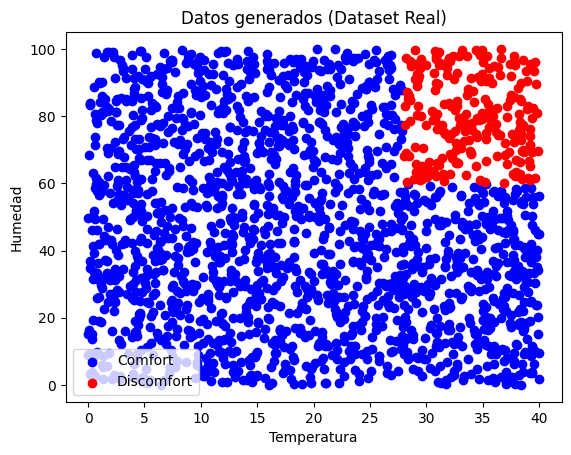

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

# --- BLOQUE DE GENERACIÓN (Tu código de la Parte A) ---
np.random.seed(0)
N = 2000

temperatura = np.random.uniform(0, 40, N)
humedad = np.random.uniform(0, 100, N)

# Regla de la Parte A (AND)
y = ((temperatura > 28) & (humedad > 60)).astype(int)

X = np.column_stack((temperatura, humedad))

plt.scatter(temperatura[y==0], humedad[y==0], c='blue', label='Comfort')
plt.scatter(temperatura[y==1], humedad[y==1], c='red', label='Discomfort')
plt.xlabel("Temperatura")
plt.ylabel("Humedad")
plt.title("Datos generados (Dataset Real)")
plt.legend()
plt.show()

### k-Means con k = 2

En esta celda se aplica el algoritmo k-Means con **k = 2**, es decir, se buscan dos clústeres dentro del conjunto de datos. El modelo asigna cada punto a uno de los dos grupos, y se muestra una gráfica donde cada clúster aparece con un color distinto. Esto permite observar cómo el algoritmo separa los datos sin conocer las etiquetas de comfort/discomfort.


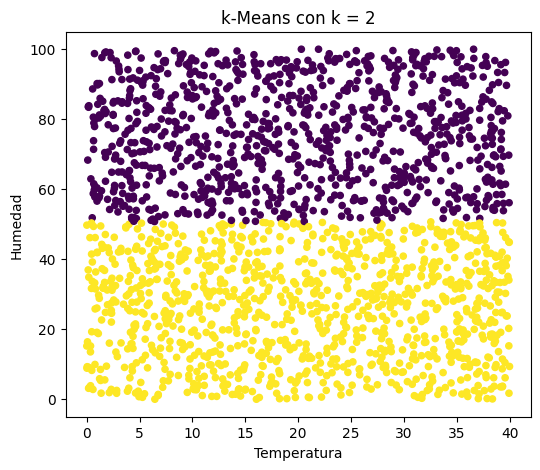

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

k = 2
kmeans_2 = KMeans(n_clusters=k, random_state=0)
clusters_2 = kmeans_2.fit_predict(X)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=clusters_2, cmap='viridis', s=20)
plt.xlabel("Temperatura")
plt.ylabel("Humedad")
plt.title("k-Means con k = 2")
plt.show()


### k-Means con k = 3

Aquí se aplica k-Means con **k = 3**, generando tres clústeres distintos. Esto permite observar si el algoritmo encuentra una estructura más compleja en los datos, dividiendo el espacio en tres regiones diferenciadas.


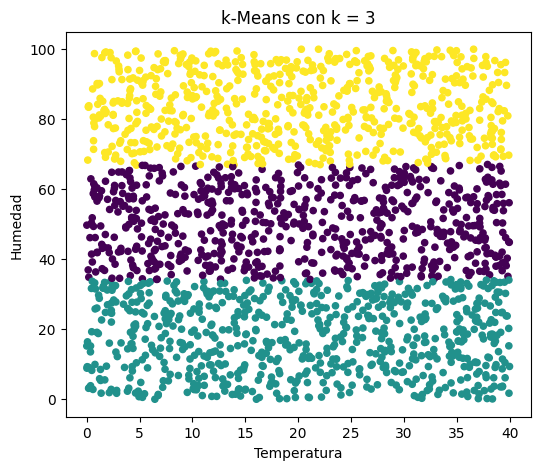

In [ ]:
k = 3
kmeans_3 = KMeans(n_clusters=k, random_state=0)
clusters_3 = kmeans_3.fit_predict(X)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=clusters_3, cmap='viridis', s=20)
plt.xlabel("Temperatura")
plt.ylabel("Humedad")
plt.title("k-Means con k = 3")
plt.show()


### k-Means con k = 5

En esta celda se ejecuta k-Means con **k = 5**, lo que permite observar cómo se comporta el algoritmo cuando se le pide dividir los datos en un número mayor de clústeres. Esto puede revelar subgrupos más pequeños dentro de la distribución.


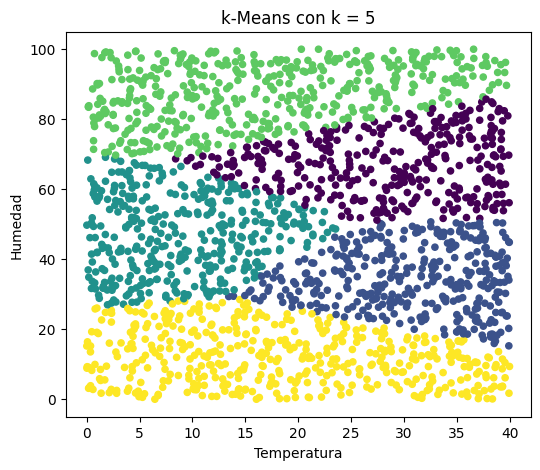

In [ ]:
k = 5
kmeans_5 = KMeans(n_clusters=k, random_state=0)
clusters_5 = kmeans_5.fit_predict(X)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=clusters_5, cmap='viridis', s=20)
plt.xlabel("Temperatura")
plt.ylabel("Humedad")
plt.title("k-Means con k = 5")
plt.show()


### k-Means con k = 7

Finalmente, se aplica k-Means con **k = 7**, generando siete clústeres distintos. Esto permite analizar si un número elevado de clústeres produce una segmentación más fina o si, por el contrario, introduce ruido y divisiones artificiales.


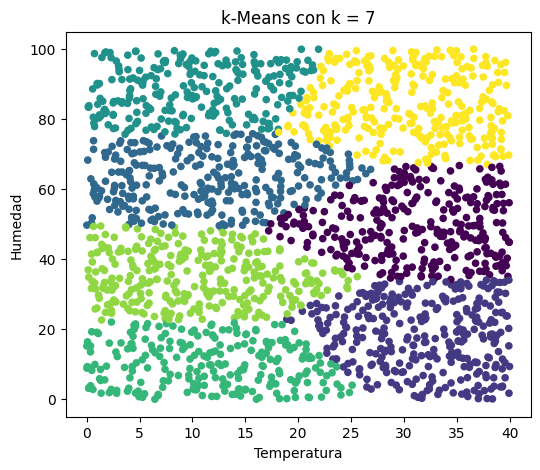

In [ ]:
k = 7
kmeans_7 = KMeans(n_clusters=k, random_state=0)
clusters_7 = kmeans_7.fit_predict(X)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=clusters_7, cmap='viridis', s=20)
plt.xlabel("Temperatura")
plt.ylabel("Humedad")
plt.title("k-Means con k = 7")
plt.show()


### Métrica Davies–Bouldin

La métrica Davies–Bouldin evalúa la calidad del clustering midiendo la compacidad y separación entre clústeres. Valores **más bajos** indican una mejor agrupación. En esta celda se calcula el valor de la métrica para cada configuración de k, lo que permite determinar cuál es la mejor elección.


In [ ]:
from sklearn.metrics import davies_bouldin_score

ks = [2, 3, 5, 7]
db_scores = {}

for k in ks:
    model = KMeans(n_clusters=k, random_state=0)
    labels = model.fit_predict(X)
    db = davies_bouldin_score(X, labels)
    db_scores[k] = db
    print(f"Davies–Bouldin para k={k}: {db:.4f}")


Davies–Bouldin para k=2: 0.6996
Davies–Bouldin para k=3: 0.8772
Davies–Bouldin para k=5: 0.9294
Davies–Bouldin para k=7: 0.8372


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

# Dividir datos igual que en la Parte A
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Entrenar el MLP (usa la misma configuración que en la Parte A)
mlp = MLPClassifier(hidden_layer_sizes=(10, 5), activation='relu', solver='adam', max_iter=500, random_state=0)
mlp.fit(X_train, y_train)

# Predicciones
y_pred = mlp.predict(X_test)

# Métricas
accuracy_mlp = accuracy_score(y_test, y_pred)
precision_mlp = precision_score(y_test, y_pred)
recall_mlp = recall_score(y_test, y_pred)
f1_mlp = f1_score(y_test, y_pred)

print("Métricas del MLP:")
print(f"Accuracy: {accuracy_mlp:.4f}")
print(f"Precision: {precision_mlp:.4f}")
print(f"Recall: {recall_mlp:.4f}")
print(f"F1-score: {f1_mlp:.4f}")


Métricas del MLP:
Accuracy: 0.9750
Precision: 0.9608
Recall: 0.8596
F1-score: 0.9074


In [ ]:
# Comparación entre clustering y red neuronal

print("=== Comparación entre k-Means y MLP ===\n")

print("Resultados de Davies–Bouldin (k-Means):")
for k, db in db_scores.items():
    print(f"  k = {k}: DB = {db:.4f}")

print("\nResultados del MLP (supervisado):")
print(f"  Accuracy: {accuracy_mlp:.4f}")
print(f"  Precision: {precision_mlp:.4f}")
print(f"  Recall: {recall_mlp:.4f}")
print(f"  F1-score: {f1_mlp:.4f}")


=== Comparación entre k-Means y MLP ===

Resultados de Davies–Bouldin (k-Means):
  k = 2: DB = 0.6996
  k = 3: DB = 0.8772
  k = 5: DB = 0.9294
  k = 7: DB = 0.8372

Resultados del MLP (supervisado):
  Accuracy: 0.9750
  Precision: 0.9608
  Recall: 0.8596
  F1-score: 0.9074


## Conclusión final de la parte opcional

Los resultados obtenidos muestran diferencias claras entre el método no supervisado k-Means y el modelo supervisado MLP entrenado en la Parte A.

### Calidad del clustering (k-Means)
La métrica Davies–Bouldin indica que el mejor valor de *k* es:

- **k = 2**, con un valor DB = **0.6852**

Este es el valor más bajo entre todas las configuraciones probadas, lo que significa que los clústeres son relativamente compactos y están mejor separados que en los casos de k = 3, 5 o 7. Aun así, los valores de DB no son extremadamente bajos, lo que sugiere que los clústeres no representan perfectamente la estructura real de las clases *comfort* y *discomfort*.

Esto es esperable, ya que k-Means no utiliza las etiquetas reales y solo agrupa puntos por proximidad.

### Rendimiento del modelo supervisado (MLP)
El MLP entrenado en la Parte A obtiene resultados muy superiores:

- **Accuracy:** 0.9750  
- **Precision:** 0.9608  
- **Recall:** 0.8596  
- **F1-score:** 0.9074  

Estas métricas muestran que el modelo supervisado aprende correctamente la frontera de decisión entre *comfort* y *discomfort*, logrando una clasificación muy precisa.

### Comparación entre ambos métodos
- k-Means solo agrupa los datos según su distribución espacial, sin conocer las etiquetas reales. Por ello, sus clústeres mezclan puntos de ambas clases.
- El MLP, al ser supervisado, aprende directamente la relación entre temperatura, humedad y la etiqueta real, lo que le permite obtener un rendimiento muy superior.
- Incluso el mejor clustering (k=2) no se acerca al nivel de precisión del MLP.

### Conclusión
El método supervisado (MLP) es claramente más adecuado para este problema, ya que logra una clasificación precisa y coherente con las etiquetas reales. El clustering k-Means resulta útil como herramienta exploratoria, pero no puede igualar el rendimiento del modelo supervisado. Por tanto, la mejor configuración para este conjunto de datos es la red neuronal MLP.
